# Advanced Segmentation Method (Mean Shift)

### Setup & libraries

In [175]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# connect Google Drive
drive.mount('/content/drive')

# defining paths
base_path = '/content/drive/MyDrive/EWS-Dataset'
train_path = os.path.join(base_path, 'train')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Help function to load images
Loads the Original picture & the corresponding ground-truth-mask

In [176]:

def load_image_and_mask(folder_path, index=0):  # index of img
    # find all normal pictures (no mask)
    image_files = sorted([f for f in os.listdir(folder_path) if not f.endswith('mask.png') and f.endswith(('.jpg', '.png'))])

    img_name = image_files[index]
    img_path = os.path.join(folder_path, img_name)

    # mask img
    mask_name = img_name.rsplit('.', 1)[0] + '_mask.png'
    mask_path = os.path.join(folder_path, mask_name)

    # load img (BGR to RGB for the original img)
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # load mask (grayscale, because its only black & white)
    true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # make the mask binary(0/1)
    _, true_mask = cv2.threshold(true_mask, 127, 1, cv2.THRESH_BINARY)
    # invert mask -> Wheat=1; soil=0
    true_mask = 1- true_mask

    return img_rgb, true_mask, img_name

# testing
test_img, test_true_mask, img_name = load_image_and_mask(train_path, index=10)
print(f"Img loaded: {img_name}")

Img loaded: FPWW0220032_RGB1_20180411_113950_6.png


## Advanced Segmentation Methods

#### Watershed

In [177]:
def segment_wheat_watershed(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    # rough mask for start
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    rough_mask = cv2.inRange(hsv, np.array([25, 35, 35]), np.array([95, 255, 255]))

    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(rough_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # sure background (via dilation)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # sure foreground (via distance transform)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.15 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg) # unknown region


    # Markers for Watershed
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(image_bgr, markers)

    result = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    result[markers > 1] = 1  # Wheat=1
    return result

#### Superpixel + Classification

In [178]:
from skimage.segmentation import slic
from skimage.filters import threshold_otsu

def segment_wheat_superpixel(image_rgb, n_segments=800, compactness=20):
    segments = slic(image_rgb, n_segments=n_segments, compactness=compactness, sigma=1, start_label=1)

    # image values to 0.0 - 1.0 for index calculation
    img_float = image_rgb.astype(float) / 255.0
    R, G, B = img_float[:, :, 0], img_float[:, :, 1], img_float[:, :, 2]

    ExG = 2 * G - R - B # Excess Green Index (highlights green vegetation & pushes brown soil into negative values)

    result = np.zeros(image_rgb.shape[:2], dtype=np.uint8)
    unique_segments = np.unique(segments)

    mean_exg_values = np.zeros(len(unique_segments)) # list for the average ExG values of each superpixel

    # calculate average ExG for each superpixel
    for i, seg_id in enumerate(unique_segments):
        mean_exg = np.mean(ExG[segments == seg_id])
        mean_exg_values[i] = mean_exg

    # find automatic threshold
    try:
        optimal_threshold = threshold_otsu(mean_exg_values) # threshold_otsu: analyzes all values & mathematically finds the best split point between back- & foreground
    except ValueError:
        optimal_threshold = 0.05 # Fallback value if Otsu fails

    # Classify superpixels
    for i, seg_id in enumerate(unique_segments):
        if mean_exg_values[i] > optimal_threshold:  # if average green value of superpixel is above threshold -> Wheat
            result[segments == seg_id] = 1

    # remove noise
    kernel = np.ones((3, 3), np.uint8)
    result = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel)
    result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)

    return result

### Evaluation & Visualization
IoU (Intersection over Union metric)

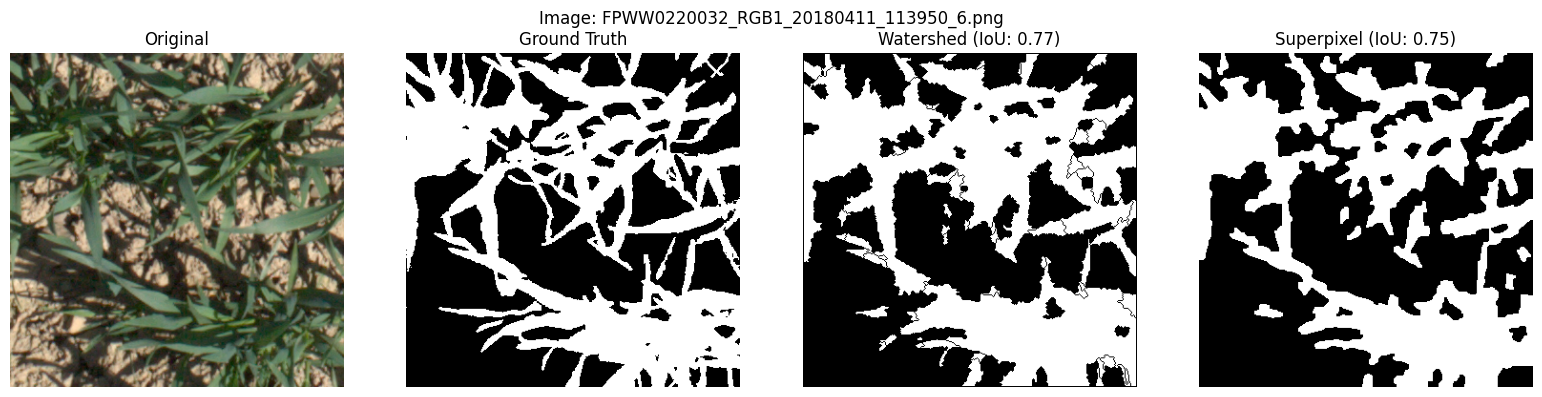

In [179]:
def evaluate_all_methods(folder_path, index=0):
    img, true_mask, name = load_image_and_mask(folder_path, index)

    # generate mask
    m_water = segment_wheat_watershed(img)
    m_super = segment_wheat_superpixel(img)

    # calculate IoUs
    iou_water = calculate_iou(true_mask, m_water)
    iou_super = calculate_iou(true_mask, m_super)

    # plotting
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(true_mask * 255, cmap="gray", vmin=0, vmax=255); ax[1].set_title("Ground Truth"); ax[1].axis("off")
    ax[2].imshow(m_water * 255, cmap="gray", vmin=0, vmax=255); ax[2].set_title(f"Watershed (IoU: {iou_water:.2f})"); ax[2].axis("off")
    ax[3].imshow(m_super * 255, cmap="gray", vmin=0, vmax=255); ax[3].set_title(f"Superpixel (IoU: {iou_super:.2f})"); ax[3].axis("off")

    plt.suptitle(f"Image: {name}"); plt.tight_layout(); plt.show()

# execute
evaluate_all_methods(train_path, index=10)

In [180]:
def test_multiple_images_text(folder_path, indices):
    methods = {
        "Watershed":   segment_wheat_watershed,
        "Superpixel":  segment_wheat_superpixel,
    }
    # collect IoU-values per method
    scores = {name: [] for name in methods}

    print(f"{'img(index)':<10} {'Watershed':>12} {'Superpixel':>12}")
    print("-" * 38)

    for idx in indices:
        image_rgb, true_mask, img_name = load_image_and_mask(folder_path, idx)
        row = f"{idx:<10}"
        for name, fn in methods.items():
            iou = calculate_iou(true_mask, fn(image_rgb))
            scores[name].append(iou)
            row += f"{iou:>12.4f}"
        print(row)

    print("-" * 38)
    avg_row = f"{'Average:':<10}"
    for name in methods:
        avg_row += f"{np.mean(scores[name]):>12.4f}"
    print(avg_row)

# Execute
test_multiple_images_text(train_path, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

img(index)    Watershed   Superpixel
--------------------------------------
0               0.5968      0.6461
1               0.5071      0.6731
2               0.3200      0.4011
3               0.4732      0.5203
4               0.4451      0.5974
5               0.2194      0.4468
6               0.2712      0.4567
7               0.5570      0.6612
8               0.4198      0.5806
9               0.6915      0.6535
10              0.7691      0.7498
11              0.7792      0.7774
12              0.7615      0.7782
--------------------------------------
Average:        0.5239      0.6109


### Simulation of Distortions
